In [2]:
!pip install -q xgboost ucimlrepo

import pandas as pd

try:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
    df = pd.read_csv(url)
except Exception:
    from ucimlrepo import fetch_ucirepo
    df = fetch_ucirepo(id=601).data.original   # fallback

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# Missing values aur duplicates check karein
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# IDs aur failure-mode columns hata dein, warna leakage hoga
df = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])

# Columns rename karein (XGBoost [ ] wale names accept nahi karta)
df = df.rename(columns={
    'Type': 'type',
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'rpm',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool_wear',
    'Machine failure': 'failure'
})

df['type'] = df['type'].map({'L': 0, 'M': 1, 'H': 2})
print(df['failure'].value_counts())   # ~3.4% failures, yani data imbalanced hai

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Duplicates: 0
failure
0    9661
1     339
Name: count, dtype: int64


In [4]:
import numpy as np

df['temp_diff'] = df['process_temp'] - df['air_temp']            # heat failure ka signal
df['power']     = df['torque'] * df['rpm'] * 2 * np.pi / 60       # watts, power failure ka signal
df['strain']    = df['tool_wear'] * df['torque']                  # overstrain ka signal

In [5]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X = df.drop('failure', axis=1)
y = df['failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scale = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                      scale_pos_weight=scale, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (8000, 9) | Test: (2000, 9)


In [6]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='f1')
print("F1 per fold:", scores.round(3))
print("Mean F1:", scores.mean().round(3), "±", scores.std().round(3))

F1 per fold: [0.636 0.629 0.337 0.597 0.767]
Mean F1: 0.593 ± 0.141


In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

oof_probs = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

best_t, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.91, 0.05):
    f1 = f1_score(y_train, (oof_probs >= t).astype(int))
    if f1 > best_f1:
        best_t, best_f1 = round(t, 2), f1

print("Best threshold:", best_t, "| F1:", round(best_f1, 3))

Best threshold: 0.8 | F1: 0.847


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

probs = model.predict_proba(X_test)[:, 1]
pred = (probs >= best_t).astype(int)

print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print("F1:", round(f1_score(y_test, pred), 4))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9915
F1: 0.8661
[[1928    4]
 [  13   55]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.81      0.87        68

    accuracy                           0.99      2000
   macro avg       0.96      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



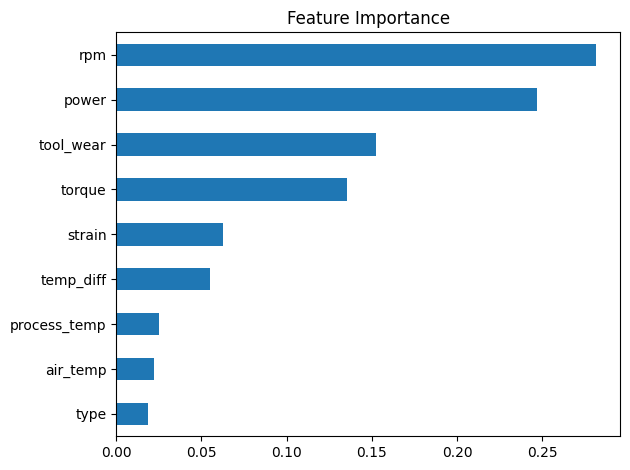

In [9]:
import matplotlib.pyplot as plt

pd.Series(model.feature_importances_, index=X.columns).sort_values().plot.barh()
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [10]:
import joblib, json
from google.colab import files

joblib.dump(model, 'model.pkl')
json.dump({"threshold": float(best_t), "features": list(X.columns)},
          open('config.json', 'w'))

files.download('model.pkl')
files.download('config.json')
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>